In [31]:
import pandas as pd
df = pd.read_csv("employee_salary_prediction_dataset.csv")
df.head()

,Employee_Id,Age,Experience_Years,Education_Level,Job_Level,Department,Performance_Score,Weekly_Working_Hours,Salary_LPA
0,1,30,6,Bachelor,2,HR,3,43.1,18.71
1,2,40,19,Bachelor,5,Marketing,8,40.8,42.69
2,3,39,14,PhD,4,Finance,2,44.8,39.37
3,4,38,10,Master,4,IT,4,37.1,33.53
4,5,34,7,Bachelor,3,IT,3,48.5,25.56


In [32]:
import pandas as pd
from sklearn.model_selection import train_test_split
df.to_csv("preprocessed_data.csv")
df.head()

,Employee_Id,Age,Experience_Years,Education_Level,Job_Level,Department,Performance_Score,Weekly_Working_Hours,Salary_LPA
0,1,30,6,Bachelor,2,HR,3,43.1,18.71
1,2,40,19,Bachelor,5,Marketing,8,40.8,42.69
2,3,39,14,PhD,4,Finance,2,44.8,39.37
3,4,38,10,Master,4,IT,4,37.1,33.53
4,5,34,7,Bachelor,3,IT,3,48.5,25.56


In [33]:
df.to_csv("preprocessed_data.csv",index=False)
print("saved")

saved


In [35]:
x = df.drop("Salary_LPA",axis=1)
y = df["Salary_LPA"]
x = pd.get_dummies(x,drop_first=True)
x_train , x_test , y_train , y_test = train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=42
)
print("Training Features: ",x_train.shape)
print("Testing Features: ",x_test.shape)

print("Training Target: ",y_train.shape)
print("Training Target: ",y_test.shape)
print("Training data")
print(x_train.head())

print("\nTesting data")
print(x_test.head())

Training Features:  (1199, 12)
Testing Features:  (300, 12)
Training Target:  (1199,)
Training Target:  (300,)
Training data
      Employee_Id  Age  Experience_Years  Job_Level  Performance_Score  \
382           383   39                20          6                  1   
538           539   43                17          6                  6   
1492         1493   37                16          5                  9   
1112         1113   34                14          4                  2   
324           325   27                 7          2                  7   

      Weekly_Working_Hours  Education_Level_Master  Education_Level_PhD  \
382                   45.5                   False                False   
538                   45.6                    True                False   
1492                  44.9                   False                False   
1112                  45.5                   False                 True   
324                   41.0                    True     

In [36]:
df['Experience_Years']

0        6
1       19
2       14
3       10
4        7
        ..
1494    16
1495     7
1496     1
1497    12
1498     2
Name: Experience_Years, Length: 1499, dtype: int64

In [37]:
df['Salary_LPA']

0       18.71
1       42.69
2       39.37
3       33.53
4       25.56
        ...  
1494    46.01
1495    23.54
1496    13.49
1497    30.35
1498    16.76
Name: Salary_LPA, Length: 1499, dtype: float64

In [39]:
import numpy as np
X = df['Experience_Years']
Y = df['Salary_LPA']
m = ((X - X.mean()) * (Y - Y.mean())).sum() / ((X - X.mean()) ** 2).sum()
c = Y.mean() - m * X.mean()
Y_pred = m * X + c
print(Y_pred)
Y_pred = np.round(Y_pred).astype(int)
print(Y_pred.head())
print("Slope: ", m)
print("Intercept: ", c)

0       23.909490
1       45.056900
2       36.923281
3       30.416386
4       25.536214
          ...    
1494    40.176729
1495    25.536214
1496    15.775871
1497    33.669833
1498    17.402595
Name: Experience_Years, Length: 1499, dtype: float64
0    24
1    45
2    37
3    30
4    26
Name: Experience_Years, dtype: int64
Slope:  1.6267238484580586
Intercept:  14.149147306545931


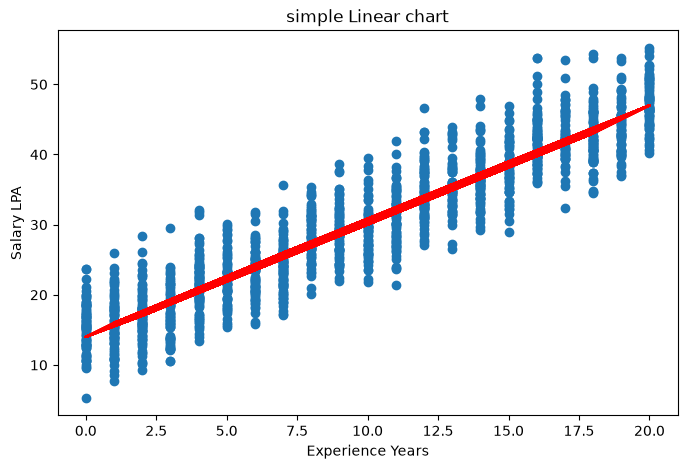

In [40]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.scatter(X,Y)
plt.plot(X,Y_pred,color = "red")
plt.title("simple Linear chart")
plt.xlabel("Experience Years")
plt.ylabel("Salary LPA")
plt.show()

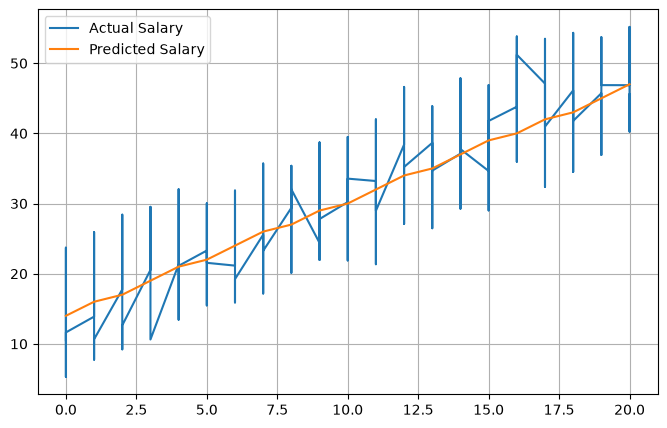

In [41]:
import matplotlib.pyplot as plt
sorted_data = pd.DataFrame({
    "X":X,
    "Actual" : Y,
    "Predicted":Y_pred
}).sort_values("X")
plt.figure(figsize=(8,5))
plt.plot(sorted_data["X"],sorted_data["Actual"],label="Actual Salary")
plt.plot(sorted_data["X"],sorted_data["Predicted"],label="Predicted Salary")
plt.title = ("Actual vs Predicted Salary")
plt.xlabel = ("Experience Years")
plt.ylabel = ("Salary LPA")
plt.legend()
plt.grid(True)
plt.show()

Intercept(b0):  14.206859004251168
Slope(b1):  1.6227614979176326

Regression Equation:
Salary = 14.206859004251168 + 1.6227614979176326 * Experience_Years
   Experience_Years  Actual Salary  Predicted Salary
0                 0          18.47                14
1                 2          20.92                17
2                 0          11.48                14
3                 0          15.74                14
4                18          42.00                43
5                19          50.74                45
6                17          42.42                42
7                 2          15.94                17
8                14          35.32                37
9                 1          13.91                16


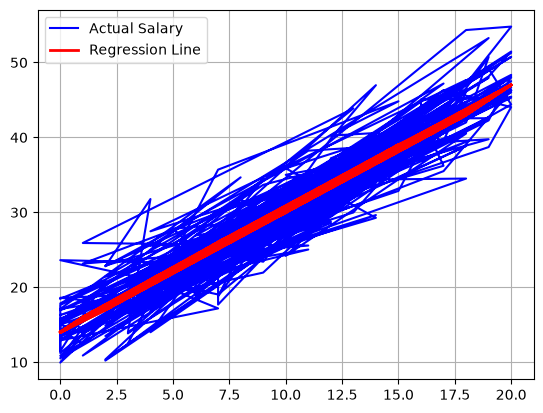

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression   
df=pd.read_csv(r'preprocessed_data.csv')
df.head()

X = df[['Experience_Years']]
y = df['Salary_LPA']
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)
model = LinearRegression()
model.fit(X_train, y_train)
print("Intercept(b0): ", model.intercept_)
print("Slope(b1): ", model.coef_[0])
print("\nRegression Equation:")
print(f"Salary = {model.intercept_} + {model.coef_[0]} * Experience_Years")
y_pred=model.predict(X_test)
y_pred = np.round(y_pred).astype(int)
result=pd.DataFrame({"Experience_Years": X_test["Experience_Years"].values,
                    "Actual Salary": y_test.values,
                    "Predicted Salary": y_pred})
print(result.head(10))
plot_data = pd.DataFrame({
    "Experience_Years": X_test["Experience_Years"].values,
    "Actual Salary": y_test.values,
    "Predicted Salary": y_pred})
plt.plot(
    plot_data["Experience_Years"],
    plot_data["Actual Salary"],
    color="blue",
    label="Actual Salary"
)
plt.plot(
    plot_data["Experience_Years"],
    plot_data["Predicted Salary"],
    color="red",
    linewidth=2,
    label="Regression Line"
)
plt.title = ("Linear Regression using scikit-learn")
plt.xlabel = ("Experience_Years")
plt.ylabel = ("Salary_LPA")
plt.legend()
plt.grid(True)
plt.show()